# Poisson Solver Demo

This notebook shows how to assemble the 2D Laplacian, build a manufactured source term for `u(x,y)=sin(pi x) sin(pi y)`, solve the discrete Poisson system, and compare numerical and analytical solutions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from finite_differences import Grid
from finite_differences.operators import laplacian_5pt
from finite_differences.poisson import solve_poisson
from finite_differences.utils import quick_plot_2d

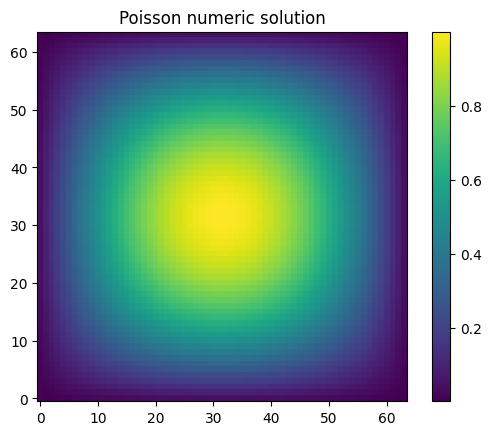

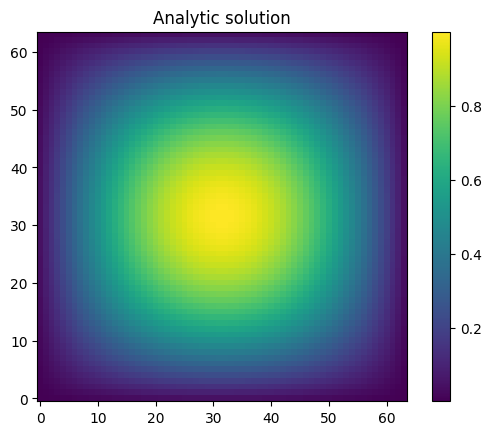

L2 error: 0.0063274085117181605


In [ ]:
# Define analytic solution and source (Dirichlet zero on boundary)
def u_exact(X, Y):
    return np.sin(np.pi * X) * np.sin(np.pi * Y)

def source_f(X, Y):
    return -2.0 * (np.pi ** 2) * u_exact(X, Y)

# Setup grid and solve
nx = 64
ny = 64
grid = Grid(nx, ny, lx=1.0, ly=1.0)
u_num = solve_poisson(grid, lambda X, Y: source_f(X, Y))
X, Y = grid.mesh()
u_ex = u_exact(X, Y)

# Show numeric and exact
fig, ax = quick_plot_2d(u_num, title="Poisson numeric solution")

plt.show()

In [ ]:
fig, ax = quick_plot_2d(u_ex, title="Analytic solution")
plt.show()
err = np.linalg.norm(u_num - u_ex)
print('L2 error:', err)

## Notes
- The solver uses the assembled 5-point Laplacian and a direct or dense fallback linear solver.
- For Galerkin/finite-volume setups or different BCs the assembly and ordering may need to be adapted.